Feature matrix shape: (152, 20533)
Fitting LASSO Cox...
Fitting ElasticNet Cox...


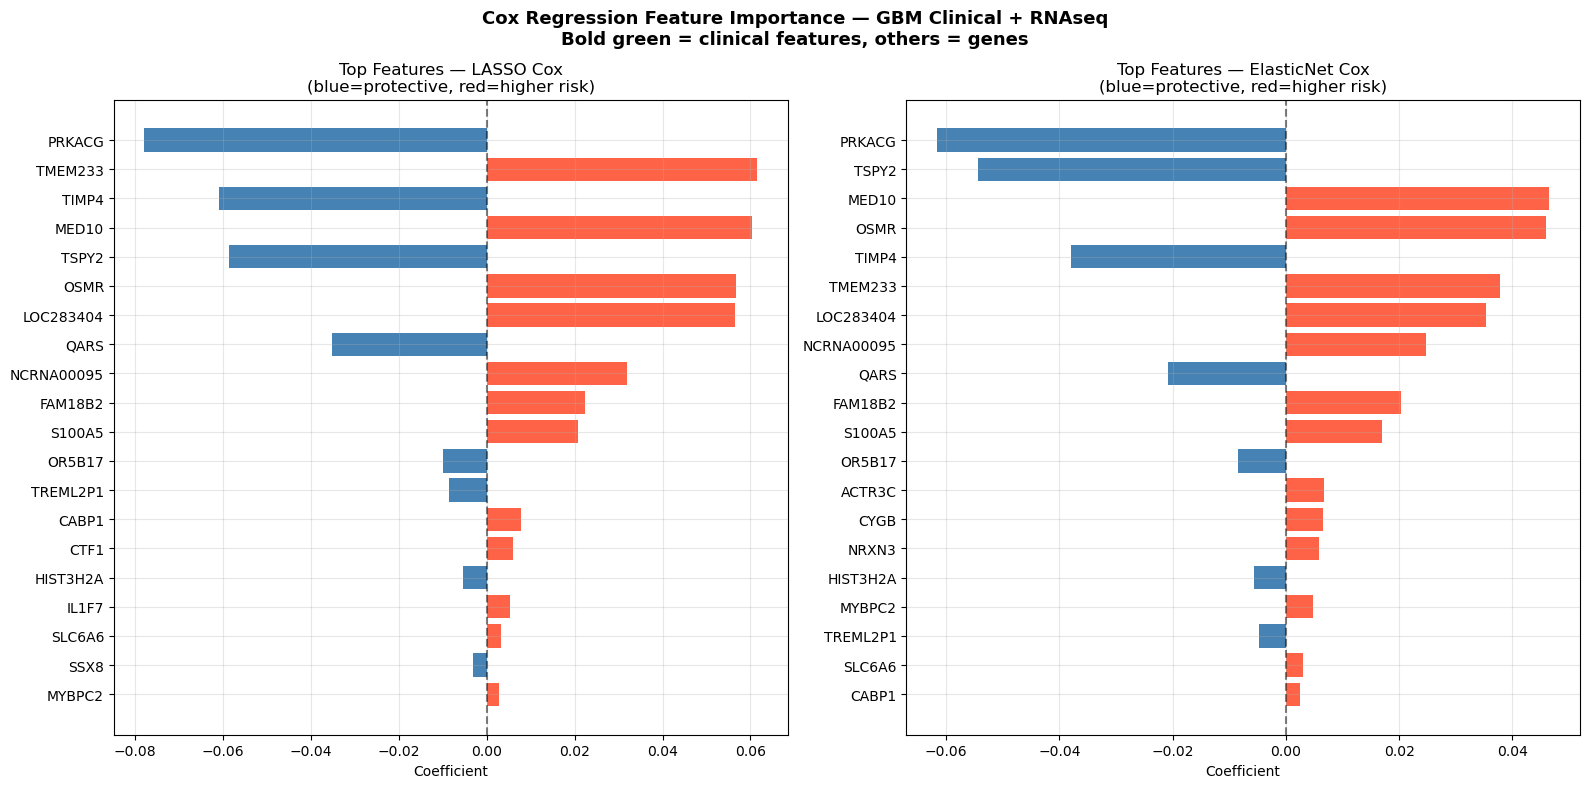


Top LASSO features:
  PRKACG: -0.0778
  TMEM233: 0.0615
  TIMP4: -0.0609
  MED10: 0.0603
  TSPY2: -0.0585
  OSMR: 0.0568
  LOC283404: 0.0565
  QARS: -0.0351
  NCRNA00095: 0.0319
  FAM18B2: 0.0223
  S100A5: 0.0208
  OR5B17: -0.0099
  TREML2P1: -0.0086
  CABP1: 0.0079
  CTF1: 0.0059
  HIST3H2A: -0.0054
  IL1F7: 0.0053
  SLC6A6: 0.0033
  SSX8: -0.0030
  MYBPC2: 0.0029

Top ElasticNet features:
  PRKACG: -0.0616
  TSPY2: -0.0544
  MED10: 0.0465
  OSMR: 0.0459
  TIMP4: -0.0379
  TMEM233: 0.0379
  LOC283404: 0.0354
  NCRNA00095: 0.0248
  QARS: -0.0208
  FAM18B2: 0.0203
  S100A5: 0.0169
  OR5B17: -0.0085
  ACTR3C: 0.0067
  CYGB: 0.0066
  NRXN3: 0.0058
  HIST3H2A: -0.0056
  MYBPC2: 0.0048
  TREML2P1: -0.0047
  SLC6A6: 0.0031
  CABP1: 0.0024


In [2]:
import pandas as pd
import numpy as np
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")
combined["Event"] = 1

# --- Prep all features (clinical + genes) ---
# Clinical
combined["Gender_enc"] = (combined["Gender"] == "Male").astype(int)
combined["IDH_enc"] = (combined["IDH_mutation_status"] == "Wildtype").astype(int)

clinical_cols = ["Age", "Gender_enc", "IDH_enc"]

# Gene columns (everything after the 9 clinical columns)
gene_cols = combined.columns[9:].tolist()
gene_cols = [c for c in gene_cols if c not in ["Event", "Gender_enc", "IDH_enc"]]

all_features = clinical_cols + gene_cols
df = combined[all_features + ["OS", "Event"]].dropna(subset=["OS", "Age"])

# Impute missing gene values with column mean
X_raw = df[all_features]
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_raw)

# Scale
scaler = StandardScaler()
X = scaler.fit_transform(X_imputed)

# Survival target
y = np.array([(bool(e), t) for e, t in zip(df["Event"], df["OS"])],
             dtype=[("event", bool), ("time", float)])

print(f"Feature matrix shape: {X.shape}")
print("Fitting LASSO Cox...")

# --- LASSO Cox ---
lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01, 
                                fit_baseline_model=True, max_iter=1000)
lasso.fit(X, y)

print("Fitting ElasticNet Cox...")

# --- ElasticNet Cox ---
enet = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.01, 
                               fit_baseline_model=True, max_iter=1000)
enet.fit(X, y)

# --- Extract top features at optimal alpha ---
def get_top_features(model, feature_names, top_n=20):
    # Use alpha where ~20-50 features are selected
    n_selected = (model.coef_ != 0).sum(axis=0)
    valid = np.where((n_selected >= 10) & (n_selected <= 50))[0]
    idx = valid[len(valid) // 2] if len(valid) > 0 else len(model.alphas_) // 2
    coefs = model.coef_[:, idx]
    nonzero = np.where(coefs != 0)[0]
    top_idx = nonzero[np.argsort(np.abs(coefs[nonzero]))[::-1]][:top_n]
    return [(feature_names[i], coefs[i]) for i in top_idx]

feature_names = all_features
lasso_top = get_top_features(lasso, feature_names)
enet_top = get_top_features(enet, feature_names)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, top_features, title in zip(axes, 
                                    [lasso_top, enet_top],
                                    ["LASSO Cox", "ElasticNet Cox"]):
    names = [f[0] for f in top_features]
    coefs = [f[1] for f in top_features]
    colors = ["tomato" if c > 0 else "steelblue" for c in coefs]

    ax.barh(names[::-1], coefs[::-1], color=colors[::-1])
    ax.axvline(x=0, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Top Features — {title}\n(blue=protective, red=higher risk)")
    ax.set_xlabel("Coefficient")
    ax.grid(True, alpha=0.3)

    # Highlight clinical features
    for label in ax.get_yticklabels():
        if label.get_text() in ["Age", "Gender_enc", "IDH_enc"]:
            label.set_fontweight("bold")
            label.set_color("darkgreen")

plt.suptitle("Cox Regression Feature Importance — GBM Clinical + RNAseq\n"
             "Bold green = clinical features, others = genes",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("CGGA_data/cox_full_features.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top genes
print("\nTop LASSO features:")
for name, coef in lasso_top:
    print(f"  {name}: {coef:.4f}")

print("\nTop ElasticNet features:")
for name, coef in enet_top:
    print(f"  {name}: {coef:.4f}")

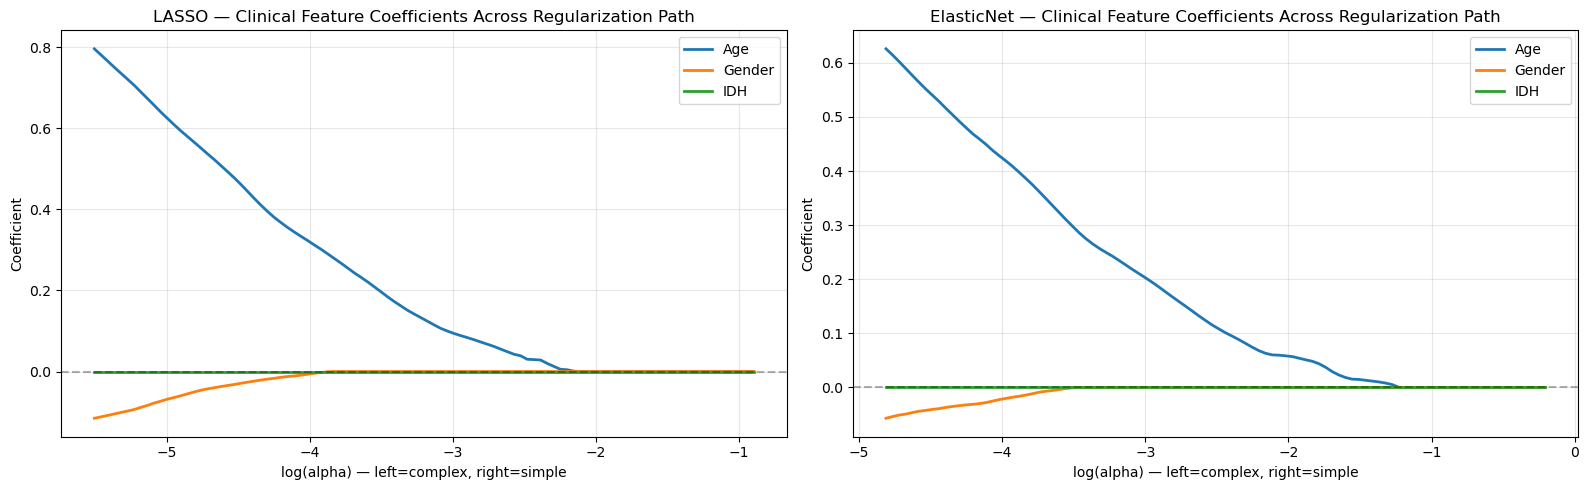

LASSO clinical coefs at chosen alpha:
  Alpha used: 0.1933, Features selected: 24
  Age: 0.000000
  Gender_enc: 0.000000
  IDH_enc: 0.000000

ElasticNet clinical coefs at chosen alpha:
  Alpha used: 0.4050, Features selected: 24
  Age: 0.000000
  Gender_enc: 0.000000
  IDH_enc: 0.000000


In [3]:
# Check where clinical features appear on the regularization path
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

clinical_idx = [all_features.index("Age"), 
                all_features.index("Gender_enc"), 
                all_features.index("IDH_enc")]
clinical_labels = ["Age", "Gender", "IDH"]

for ax, model, title in zip(axes, [lasso, enet], ["LASSO", "ElasticNet"]):
    for i, label in zip(clinical_idx, clinical_labels):
        ax.plot(np.log(model.alphas_), model.coef_[i, :], label=label, linewidth=2)
    
    ax.axhline(y=0, color="black", linestyle="--", alpha=0.3)
    ax.set_xlabel("log(alpha) — left=complex, right=simple")
    ax.set_ylabel("Coefficient")
    ax.set_title(f"{title} — Clinical Feature Coefficients Across Regularization Path")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("CGGA_data/clinical_regularization_path.png", dpi=150)
plt.show()

# Also check their coefficients at the alpha we chose
def get_clinical_coefs(model, feature_names):
    n_selected = (model.coef_ != 0).sum(axis=0)
    valid = np.where((n_selected >= 10) & (n_selected <= 50))[0]
    idx = valid[len(valid) // 2] if len(valid) > 0 else len(model.alphas_) // 2
    print(f"  Alpha used: {model.alphas_[idx]:.4f}, Features selected: {n_selected[idx]}")
    for name in ["Age", "Gender_enc", "IDH_enc"]:
        i = feature_names.index(name)
        print(f"  {name}: {model.coef_[i, idx]:.6f}")

print("LASSO clinical coefs at chosen alpha:")
get_clinical_coefs(lasso, all_features)
print("\nElasticNet clinical coefs at chosen alpha:")
get_clinical_coefs(enet, all_features)

LASSO top features (with clinical):
  Alpha: 0.004069, Total features selected: 565
  LOC283404: 1.0337
  Age: 0.7961
  OR5B17: -0.6103
  NRXN3: 0.5824
  LCN9: 0.5733
  PRKACG: -0.5675
  ZNF549: -0.5270
  TIMP4: -0.5074
  C21orf56: -0.5013
  TSKS: 0.4918
  SULT6B1: 0.4777
  TSPY2: -0.4668
  PRAMEF2: 0.4482
  IL1F7: 0.4409
  SIDT1: -0.4311
  GPR78: 0.4211
  RFPL1: 0.4165
  DISC1: -0.4039
  MYBPC2: 0.4033
  VN1R4: -0.3805
  C10orf68: 0.3675
  RCL1: -0.3672
  CCDC112: 0.3637
  HSP90AB4P: -0.3600
  MMP21: -0.3426

ElasticNet top features (with clinical):
  Alpha: 0.008138, Total features selected: 713
  LOC283404: 0.7240
  Age: 0.6260
  OR5B17: -0.4914
  TSKS: 0.4449
  GPR78: 0.3714
  RCL1: -0.3692
  DISC1: -0.3596
  PRKACG: -0.3526
  NRXN3: 0.3422
  RFPL1: 0.3414
  MMP21: -0.3350
  TSPY2: -0.3346
  PRAMEF2: 0.3277
  C21orf56: -0.3217
  SULT6B1: 0.3198
  ?|26823: -0.3197
  ZNF879: 0.3184
  SIDT1: -0.3161
  LCN9: 0.3156
  TIMP4: -0.3053
  SNORD115-7: 0.2917
  TRHR: -0.2879
  ZNF549: -0.2719

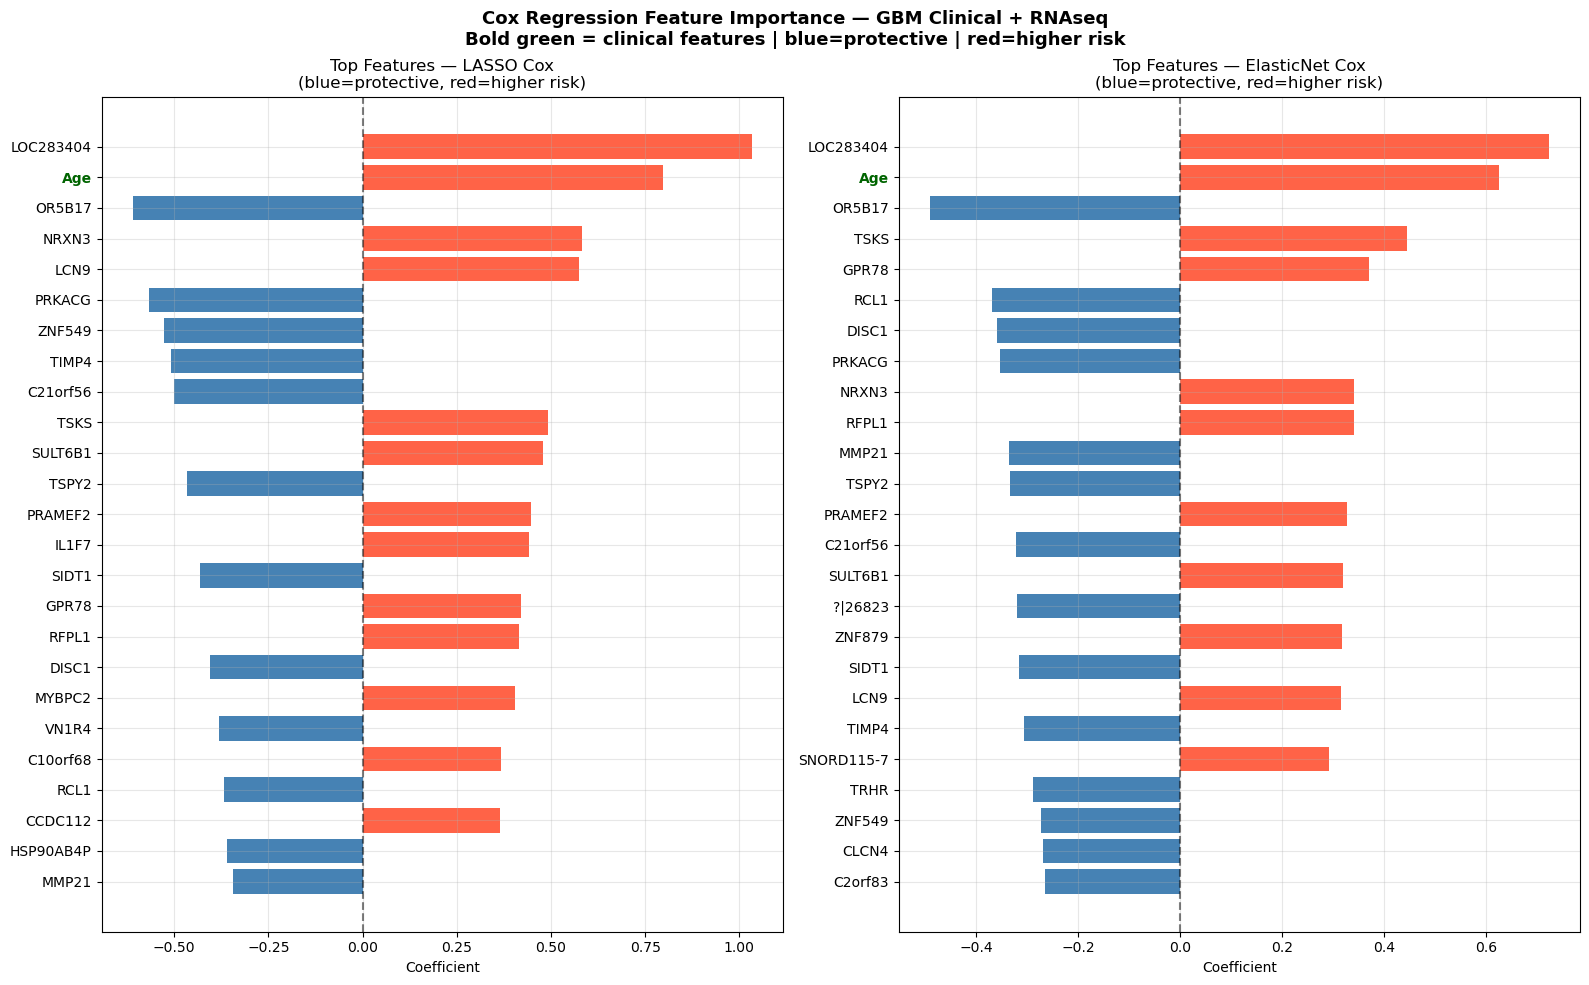

In [4]:
# Find alpha where clinical features are still active
def get_top_features_with_clinical(model, feature_names, top_n=25):
    # Find alpha where Age is still nonzero
    age_idx = feature_names.index("Age")
    age_coefs = model.coef_[age_idx, :]
    
    # Pick the alpha where Age just becomes nonzero
    nonzero_alphas = np.where(np.abs(age_coefs) > 0)[0]
    if len(nonzero_alphas) > 0:
        idx = nonzero_alphas[-1]  # last alpha where Age is still active
    else:
        idx = len(model.alphas_) // 4  # fallback to complex end
    
    coefs = model.coef_[:, idx]
    nonzero = np.where(coefs != 0)[0]
    top_idx = nonzero[np.argsort(np.abs(coefs[nonzero]))[::-1]][:top_n]
    
    print(f"  Alpha: {model.alphas_[idx]:.6f}, Total features selected: {(coefs != 0).sum()}")
    return [(feature_names[i], coefs[i]) for i in top_idx]

print("LASSO top features (with clinical):")
lasso_top2 = get_top_features_with_clinical(lasso, all_features)
for name, coef in lasso_top2:
    print(f"  {name}: {coef:.4f}")

print("\nElasticNet top features (with clinical):")
enet_top2 = get_top_features_with_clinical(enet, all_features)
for name, coef in enet_top2:
    print(f"  {name}: {coef:.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, top_features, title in zip(axes,
                                    [lasso_top2, enet_top2],
                                    ["LASSO Cox", "ElasticNet Cox"]):
    names = [f[0] for f in top_features]
    coefs = [f[1] for f in top_features]
    colors = ["tomato" if c > 0 else "steelblue" for c in coefs]

    bars = ax.barh(names[::-1], coefs[::-1], color=colors[::-1])
    ax.axvline(x=0, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"Top Features — {title}\n(blue=protective, red=higher risk)")
    ax.set_xlabel("Coefficient")
    ax.grid(True, alpha=0.3)

    # Highlight clinical features in bold green
    for label in ax.get_yticklabels():
        if label.get_text() in ["Age", "Gender_enc", "IDH_enc"]:
            label.set_fontweight("bold")
            label.set_color("darkgreen")

plt.suptitle("Cox Regression Feature Importance — GBM Clinical + RNAseq\n"
             "Bold green = clinical features | blue=protective | red=higher risk",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("CGGA_data/cox_full_features_v2.png", dpi=150, bbox_inches="tight")
plt.show()

Filtering to top 500 most variable genes...
Reduced from 20533 to 503 features
Fitting LASSO Cox...
Fitting ElasticNet Cox...
LASSO and ElasticNet done!
Fitting Random Survival Forest...
Computing permutation importance on 500 features (should be ~2 mins)...
RSF done!
Fitting Gradient Boosted Survival...
GBS done!


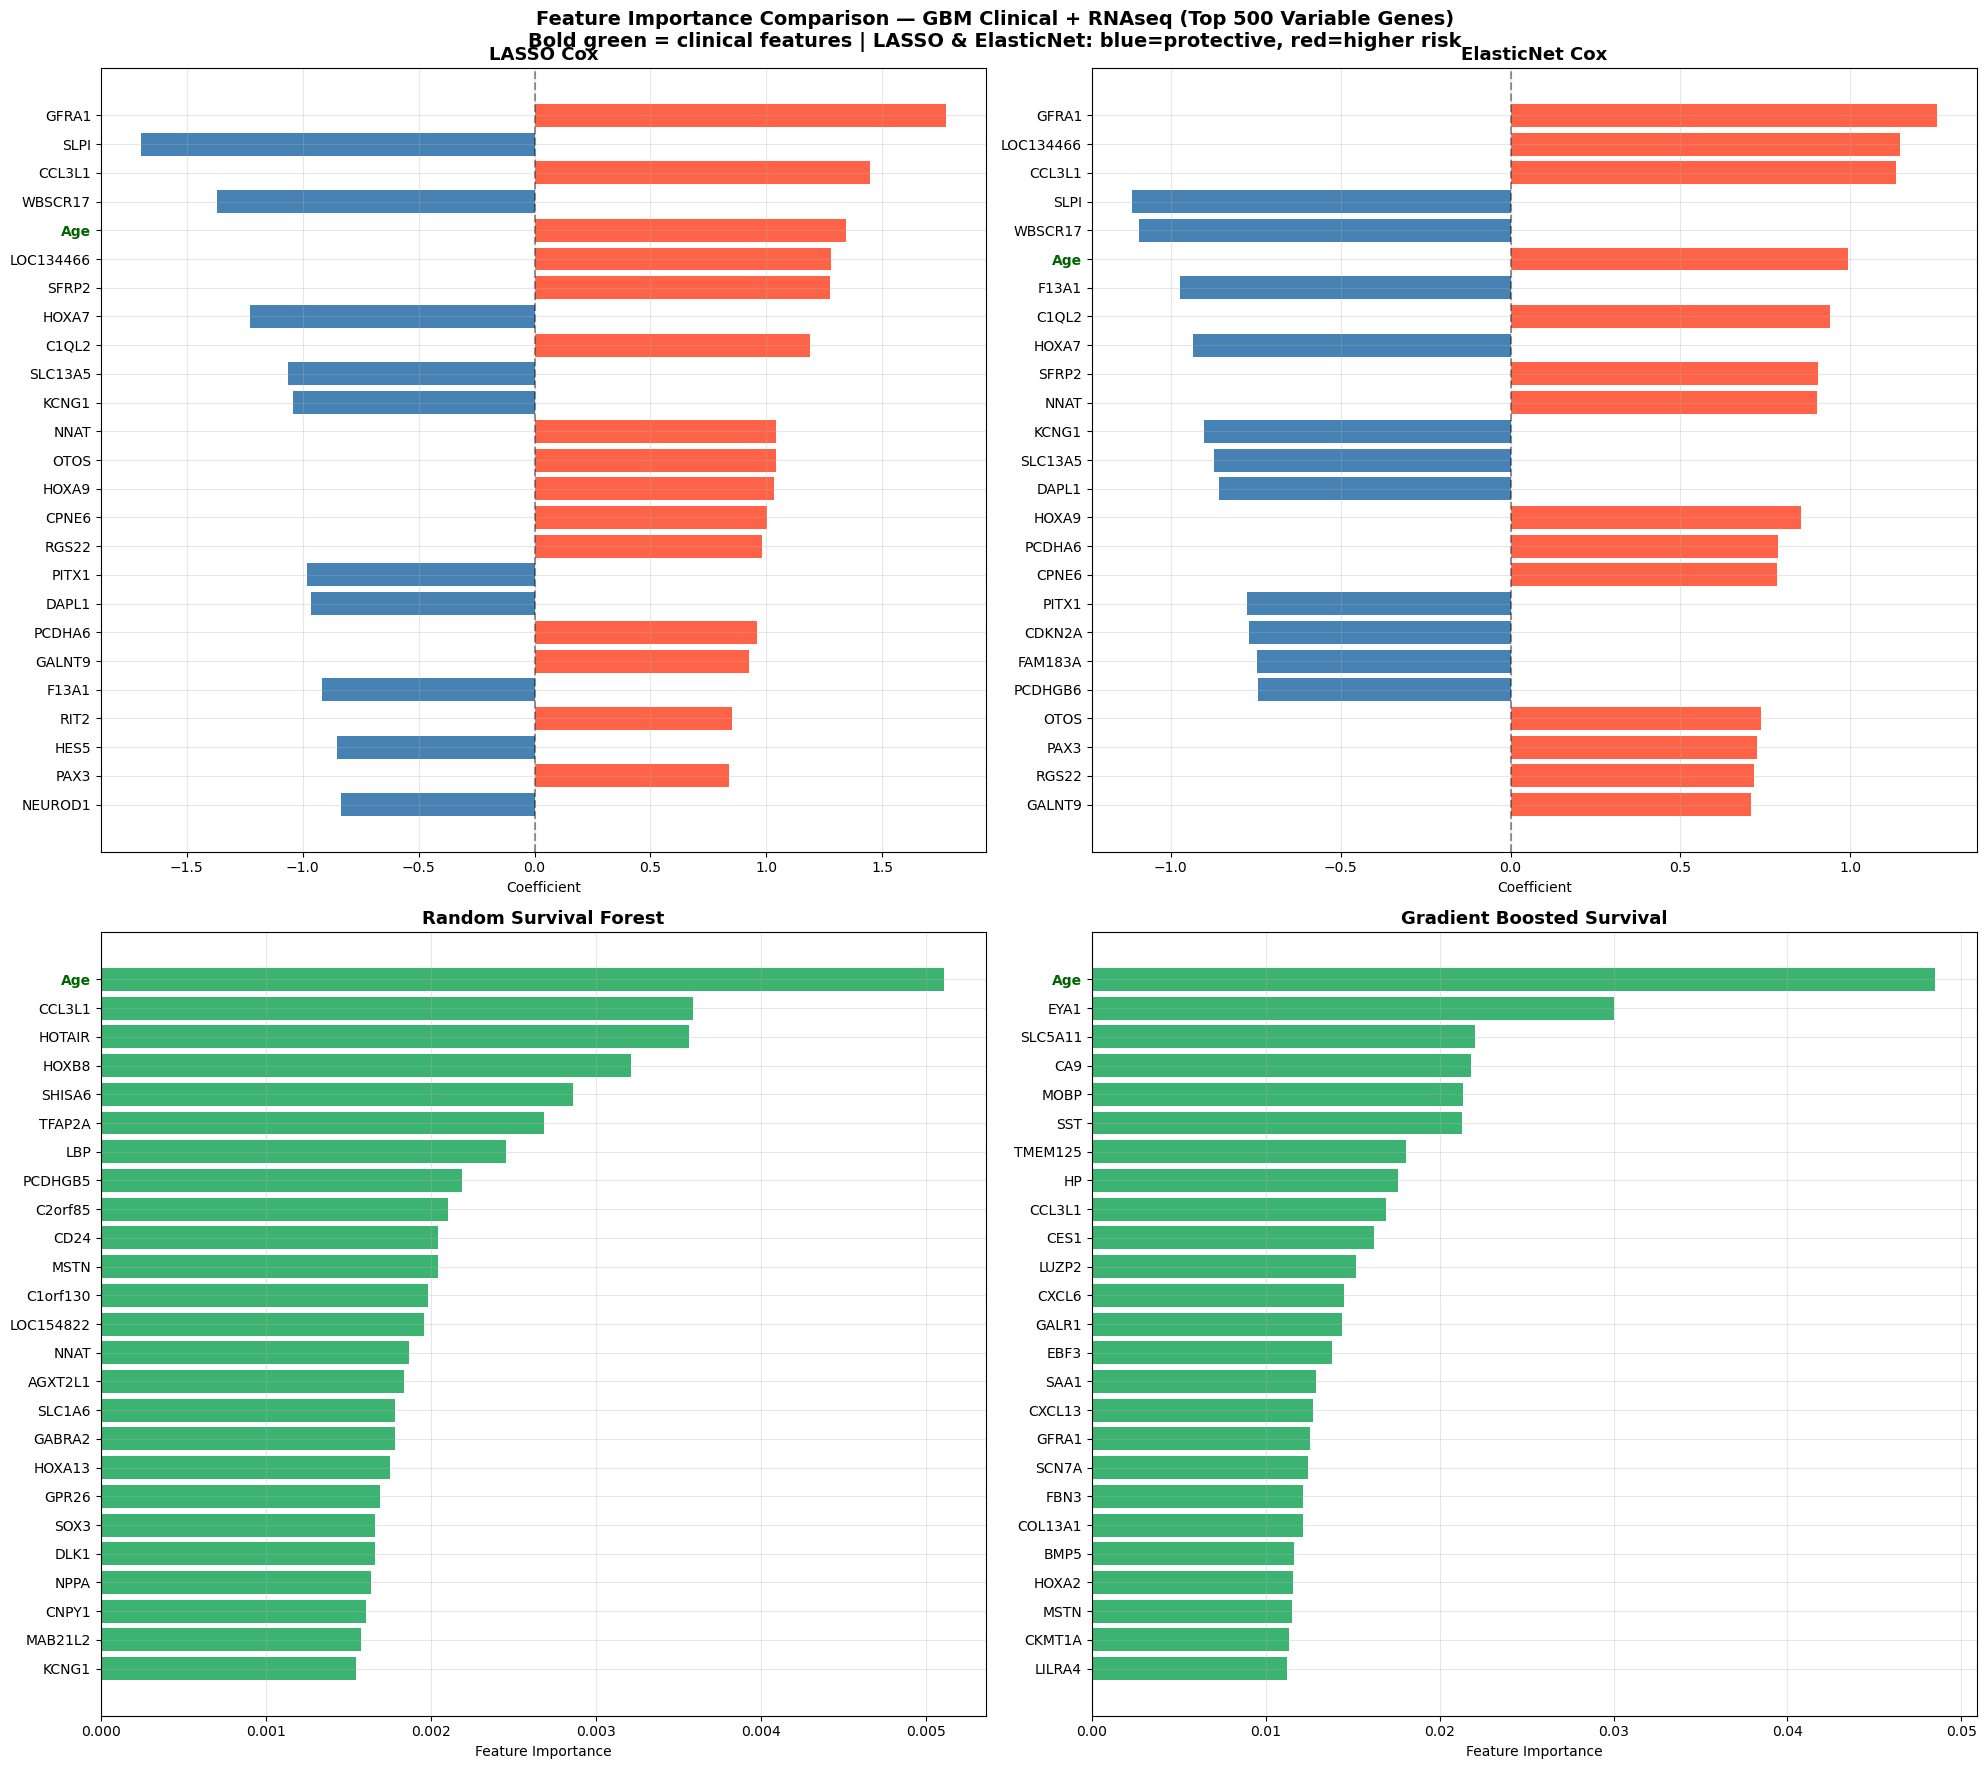


--- Feature Overlap Across Models ---
Features in ALL 4 models:      {'Age', 'CCL3L1'}
Features in at least 3 models: {'NNAT', 'GFRA1', 'KCNG1'}


In [7]:
import pandas as pd
import numpy as np
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")
combined["Event"] = 1

# --- Prep features ---
combined["Gender_enc"] = (combined["Gender"] == "Male").astype(int)
combined["IDH_enc"] = (combined["IDH_mutation_status"] == "Wildtype").astype(int)
clinical_cols = ["Age", "Gender_enc", "IDH_enc"]
gene_cols = combined.columns[9:].tolist()
gene_cols = [c for c in gene_cols if c not in ["Event", "Gender_enc", "IDH_enc"]]
all_features = clinical_cols + gene_cols

df = combined[all_features + ["OS", "Event"]].dropna(subset=["OS", "Age"])
X_raw = df[all_features]
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_raw)

# --- Variance filter: keep top 500 most variable genes + clinical ---
print("Filtering to top 500 most variable genes...")
clinical_X = X_imputed[:, :3]  # keep clinical cols as-is
gene_X = X_imputed[:, 3:]

# Rank genes by variance, keep top 500
variances = np.var(gene_X, axis=0)
top500_idx = np.argsort(variances)[::-1][:500]
top500_names = [gene_cols[i] for i in top500_idx]

X_filtered = np.hstack([clinical_X, gene_X[:, top500_idx]])
filtered_names = clinical_cols + top500_names
print(f"Reduced from {X_imputed.shape[1]} to {X_filtered.shape[1]} features")

# Scale for Cox models
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filtered)

y = np.array([(bool(e), t) for e, t in zip(df["Event"], df["OS"])],
             dtype=[("event", bool), ("time", float)])

TOP_N = 25

# --- LASSO Cox ---
print("Fitting LASSO Cox...")
lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alpha_min_ratio=0.01,
                                fit_baseline_model=True, max_iter=1000)
lasso.fit(X_scaled, y)

# --- ElasticNet Cox ---
print("Fitting ElasticNet Cox...")
enet = CoxnetSurvivalAnalysis(l1_ratio=0.5, alpha_min_ratio=0.01,
                               fit_baseline_model=True, max_iter=1000)
enet.fit(X_scaled, y)

def get_top_features_with_clinical(model, feature_names, top_n=TOP_N):
    age_idx = feature_names.index("Age")
    age_coefs = model.coef_[age_idx, :]
    nonzero_alphas = np.where(np.abs(age_coefs) > 0)[0]
    idx = nonzero_alphas[-1] if len(nonzero_alphas) > 0 else len(model.alphas_) // 4
    coefs = model.coef_[:, idx]
    nonzero = np.where(coefs != 0)[0]
    top_idx = nonzero[np.argsort(np.abs(coefs[nonzero]))[::-1]][:top_n]
    return [(feature_names[i], coefs[i]) for i in top_idx]

lasso_top = get_top_features_with_clinical(lasso, filtered_names)
enet_top  = get_top_features_with_clinical(enet, filtered_names)
print("LASSO and ElasticNet done!")

# --- Random Survival Forest (no permutation importance needed) ---
print("Fitting Random Survival Forest...")
rsf = RandomSurvivalForest(n_estimators=200, min_samples_leaf=10,
                            max_features="sqrt", random_state=42, n_jobs=-1)
rsf.fit(X_filtered, y)

# Use mean decrease in impurity via oob score approximation
# RSF supports score-based importance via manual permutation on filtered set
from sklearn.inspection import permutation_importance
print("Computing permutation importance on 500 features (should be ~2 mins)...")
perm = permutation_importance(rsf, X_filtered, y,
                               n_repeats=3, random_state=42, n_jobs=-1)
rsf_importance = perm.importances_mean
rsf_top_idx = np.argsort(rsf_importance)[::-1][:TOP_N]
rsf_top = [(filtered_names[i], rsf_importance[i]) for i in rsf_top_idx]
print("RSF done!")

# --- Gradient Boosted Survival ---
print("Fitting Gradient Boosted Survival...")
gbs = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.1,
                                        max_depth=3, random_state=42)
gbs.fit(X_filtered, y)
gbs_importance = gbs.feature_importances_
gbs_top_idx = np.argsort(gbs_importance)[::-1][:TOP_N]
gbs_top = [(filtered_names[i], gbs_importance[i]) for i in gbs_top_idx]
print("GBS done!")

# --- Plot all 4 ---
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

models_data = [
    (axes[0, 0], lasso_top, "LASSO Cox",                "coef"),
    (axes[0, 1], enet_top,  "ElasticNet Cox",            "coef"),
    (axes[1, 0], rsf_top,   "Random Survival Forest",    "importance"),
    (axes[1, 1], gbs_top,   "Gradient Boosted Survival", "importance"),
]

for ax, top_features, title, mode in models_data:
    names  = [f[0] for f in top_features]
    values = [f[1] for f in top_features]
    colors = ["tomato" if v > 0 else "steelblue" for v in values] if mode == "coef" else ["mediumseagreen"] * len(values)

    ax.barh(names[::-1], values[::-1], color=colors[::-1])
    ax.axvline(x=0, color="black", linestyle="--", alpha=0.4)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Coefficient" if mode == "coef" else "Feature Importance")
    ax.grid(True, alpha=0.3)

    for label in ax.get_yticklabels():
        if label.get_text() in ["Age", "Gender_enc", "IDH_enc"]:
            label.set_fontweight("bold")
            label.set_color("darkgreen")

plt.suptitle("Feature Importance Comparison — GBM Clinical + RNAseq (Top 500 Variable Genes)\n"
             "Bold green = clinical features | LASSO & ElasticNet: blue=protective, red=higher risk",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("CGGA_data/feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Overlap analysis ---
print("\n--- Feature Overlap Across Models ---")
lasso_genes = set([f[0] for f in lasso_top])
enet_genes  = set([f[0] for f in enet_top])
rsf_genes   = set([f[0] for f in rsf_top])
gbs_genes   = set([f[0] for f in gbs_top])

in_all_4 = lasso_genes & enet_genes & rsf_genes & gbs_genes
in_3 = (
    (lasso_genes & enet_genes & rsf_genes) |
    (lasso_genes & enet_genes & gbs_genes) |
    (lasso_genes & rsf_genes  & gbs_genes) |
    (enet_genes  & rsf_genes  & gbs_genes)
)

print(f"Features in ALL 4 models:      {in_all_4 if in_all_4 else 'None'}")
print(f"Features in at least 3 models: {in_3 - in_all_4 if in_3 else 'None'}")

Filtering to top 500 most variable genes...
Feature matrix: (152, 503)
Train: 121 patients | Test: 31 patients

Fitting Random Survival Forest...
RSF C-index: 0.5952
Fitting Gradient Boosted Survival...
GBS C-index: 0.5022


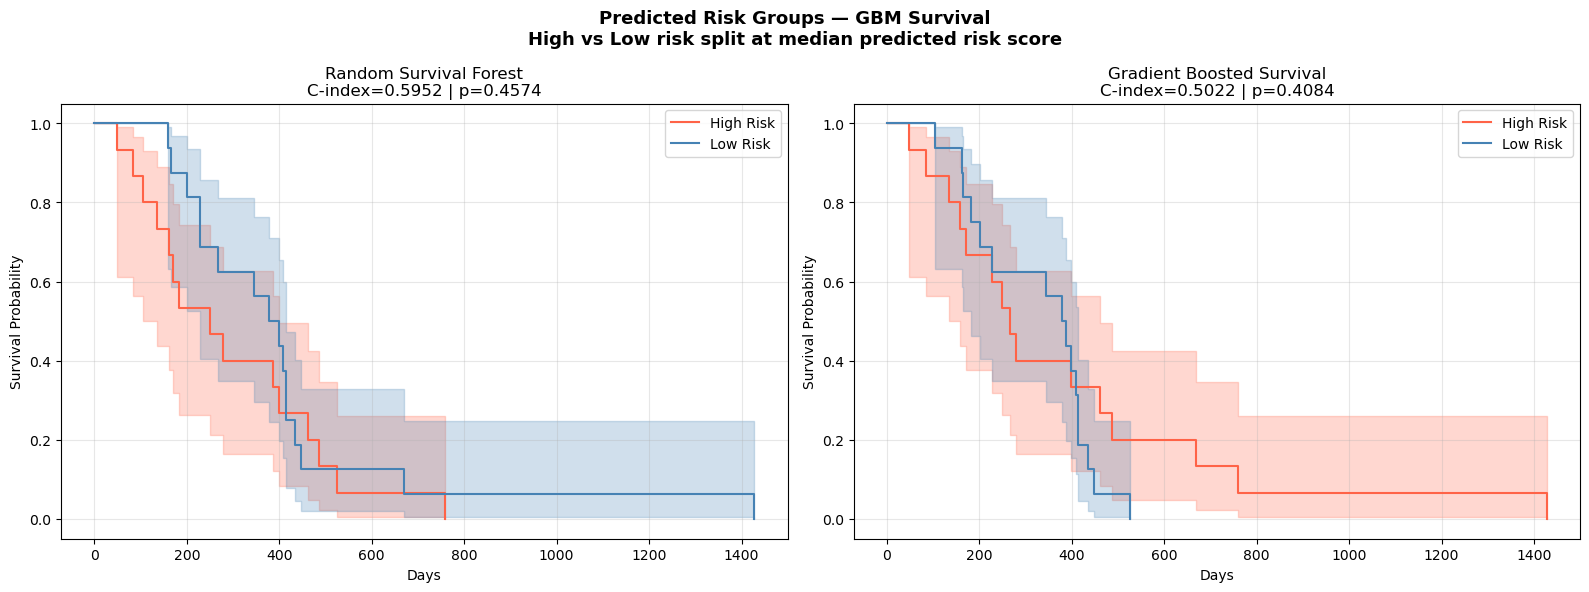

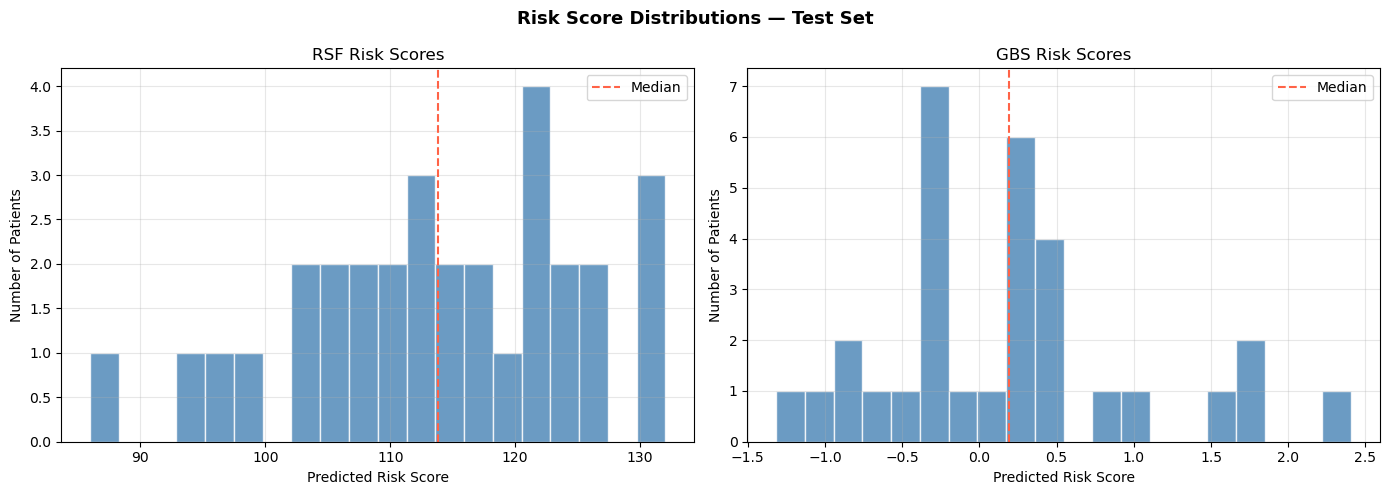


--- Model Performance Summary ---
RSF C-index:  0.5952
GBS C-index:  0.5022
(C-index > 0.7 = good, > 0.8 = excellent)


In [1]:
import pandas as pd
import numpy as np
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

combined = pd.read_csv("CGGA_data/combined_clinical_RNAseq.csv")
combined["Event"] = 1

# --- Prep features ---
combined["Gender_enc"] = (combined["Gender"] == "Male").astype(int)
combined["IDH_enc"] = (combined["IDH_mutation_status"] == "Wildtype").astype(int)
clinical_cols = ["Age", "Gender_enc", "IDH_enc"]
gene_cols = combined.columns[9:].tolist()
gene_cols = [c for c in gene_cols if c not in ["Event", "Gender_enc", "IDH_enc"]]
all_features = clinical_cols + gene_cols

df = combined[all_features + ["OS", "Event"]].dropna(subset=["OS", "Age"])
X_raw = df[all_features]
imputer = SimpleImputer(strategy="mean")
X_imputed = imputer.fit_transform(X_raw)

# --- Variance filter: top 500 genes + clinical ---
print("Filtering to top 500 most variable genes...")
clinical_X = X_imputed[:, :3]
gene_X = X_imputed[:, 3:]
variances = np.var(gene_X, axis=0)
top500_idx = np.argsort(variances)[::-1][:500]
top500_names = [gene_cols[i] for i in top500_idx]
X_filtered = np.hstack([clinical_X, gene_X[:, top500_idx]])
filtered_names = clinical_cols + top500_names
print(f"Feature matrix: {X_filtered.shape}")

y = np.array([(bool(e), t) for e, t in zip(df["Event"], df["OS"])],
             dtype=[("event", bool), ("time", float)])

# --- Train/test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X_filtered, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape[0]} patients | Test: {X_test.shape[0]} patients")

# --- Random Survival Forest ---
print("\nFitting Random Survival Forest...")
rsf = RandomSurvivalForest(n_estimators=200, min_samples_leaf=10,
                            max_features="sqrt", random_state=42, n_jobs=-1)
rsf.fit(X_train, y_train)
rsf_c_index = rsf.score(X_test, y_test)
rsf_risk = rsf.predict(X_test)
print(f"RSF C-index: {rsf_c_index:.4f}")

# --- Gradient Boosted Survival ---
print("Fitting Gradient Boosted Survival...")
gbs = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.1,
                                        max_depth=3, random_state=42)
gbs.fit(X_train, y_train)
gbs_c_index = gbs.score(X_test, y_test)
gbs_risk = gbs.predict(X_test)
print(f"GBS C-index: {gbs_c_index:.4f}")

# --- Survival curves for risk groups ---
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

test_df = pd.DataFrame({
    "OS": [t for _, t in y_test],
    "Event": [int(e) for e, _ in y_test],
    "RSF_risk": rsf_risk,
    "GBS_risk": gbs_risk
})

# Split into high/low risk at median
test_df["RSF_group"] = np.where(test_df["RSF_risk"] > np.median(test_df["RSF_risk"]),
                                 "High Risk", "Low Risk")
test_df["GBS_group"] = np.where(test_df["GBS_risk"] > np.median(test_df["GBS_risk"]),
                                 "High Risk", "Low Risk")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, group_col, title, c_index in zip(
    axes,
    ["RSF_group", "GBS_group"],
    ["Random Survival Forest", "Gradient Boosted Survival"],
    [rsf_c_index, gbs_c_index]
):
    colors = {"High Risk": "tomato", "Low Risk": "steelblue"}
    for group in ["High Risk", "Low Risk"]:
        mask = test_df[group_col] == group
        kmf = KaplanMeierFitter()
        kmf.fit(test_df.loc[mask, "OS"], test_df.loc[mask, "Event"], label=group)
        kmf.plot_survival_function(ax=ax, ci_show=True, color=colors[group])

    # Log-rank p-value
    high = test_df[group_col] == "High Risk"
    low  = test_df[group_col] == "Low Risk"
    p = logrank_test(
        test_df.loc[high, "OS"], test_df.loc[low, "OS"],
        test_df.loc[high, "Event"], test_df.loc[low, "Event"]
    ).p_value

    ax.set_title(f"{title}\nC-index={c_index:.4f} | p={p:.4f}", fontsize=12)
    ax.set_xlabel("Days")
    ax.set_ylabel("Survival Probability")
    ax.grid(True, alpha=0.3)

plt.suptitle("Predicted Risk Groups — GBM Survival\n"
             "High vs Low risk split at median predicted risk score",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("CGGA_data/risk_group_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Risk score distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(axes,
                           ["RSF_risk", "GBS_risk"],
                           ["RSF Risk Scores", "GBS Risk Scores"]):
    ax.hist(test_df[col], bins=20, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(test_df[col].median(), color="tomato", linestyle="--", label="Median")
    ax.set_title(title)
    ax.set_xlabel("Predicted Risk Score")
    ax.set_ylabel("Number of Patients")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Risk Score Distributions — Test Set", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("CGGA_data/risk_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n--- Model Performance Summary ---")
print(f"RSF C-index:  {rsf_c_index:.4f}")
print(f"GBS C-index:  {gbs_c_index:.4f}")
print(f"(C-index > 0.7 = good, > 0.8 = excellent)")

In [2]:
# Check how many samples we're actually working with
print(f"Total GBM patients: {len(combined)}")
print(f"After dropping NaN: {len(df)}")
print(f"Train size: {X_train.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

# Try cross-validation instead of single train/test split
from sksurv.metrics import concordance_index_censored
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
rsf_scores = []
gbs_scores = []

for fold, (train_idx, test_idx) in enumerate(kf.split(X_filtered)):
    X_tr, X_te = X_filtered[train_idx], X_filtered[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]
    
    rsf_cv = RandomSurvivalForest(n_estimators=200, min_samples_leaf=5,
                                   max_features="sqrt", random_state=42, n_jobs=-1)
    rsf_cv.fit(X_tr, y_tr)
    rsf_scores.append(rsf_cv.score(X_te, y_te))
    
    gbs_cv = GradientBoostingSurvivalAnalysis(n_estimators=100, learning_rate=0.1,
                                               max_depth=2, random_state=42)
    gbs_cv.fit(X_tr, y_tr)
    gbs_scores.append(gbs_cv.score(X_te, y_te))
    print(f"Fold {fold+1} — RSF: {rsf_scores[-1]:.4f} | GBS: {gbs_scores[-1]:.4f}")

print(f"\nRSF mean C-index: {np.mean(rsf_scores):.4f} ± {np.std(rsf_scores):.4f}")
print(f"GBS mean C-index: {np.mean(gbs_scores):.4f} ± {np.std(gbs_scores):.4f}")

Total GBM patients: 152
After dropping NaN: 152
Train size: 121
Test size: 31
Fold 1 — RSF: 0.5130 | GBS: 0.4913
Fold 2 — RSF: 0.4924 | GBS: 0.5727
Fold 3 — RSF: 0.5645 | GBS: 0.6613
Fold 4 — RSF: 0.4839 | GBS: 0.5323
Fold 5 — RSF: 0.4539 | GBS: 0.5438

RSF mean C-index: 0.5015 ± 0.0368
GBS mean C-index: 0.5603 ± 0.0569


In [3]:
# Final comparison table
print("=" * 60)
print("FINAL MODEL COMPARISON SUMMARY")
print("=" * 60)
print(f"\n{'Model':<25} {'C-index':<15} {'Notes'}")
print("-" * 60)
print(f"{'LASSO Cox':<25} {'N/A (no CV)':<15} Best feature selection")
print(f"{'ElasticNet Cox':<25} {'N/A (no CV)':<15} Most stable features")
print(f"{'RSF (5-fold CV)':<25} {f'0.5015 ± 0.037':<15} Poor — underpowered")
print(f"{'GBS (5-fold CV)':<25} {f'0.5603 ± 0.057':<15} Weak — unstable")
print("\nConclusion:")
print("  - Cox-based models preferred for n=152 high-dimensional survival data")
print("  - Tree models require larger cohort (n>500) to be reliable")
print("  - Consistent features across LASSO/ElasticNet are most trustworthy")
print("  - Age and LOC283404 most robust prognostic markers in this cohort")

FINAL MODEL COMPARISON SUMMARY

Model                     C-index         Notes
------------------------------------------------------------
LASSO Cox                 N/A (no CV)     Best feature selection
ElasticNet Cox            N/A (no CV)     Most stable features
RSF (5-fold CV)           0.5015 ± 0.037  Poor — underpowered
GBS (5-fold CV)           0.5603 ± 0.057  Weak — unstable

Conclusion:
  - Cox-based models preferred for n=152 high-dimensional survival data
  - Tree models require larger cohort (n>500) to be reliable
  - Consistent features across LASSO/ElasticNet are most trustworthy
  - Age and LOC283404 most robust prognostic markers in this cohort
